<a href="https://colab.research.google.com/github/lakshmanchavan/ml-models/blob/main/decisiontree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()


Saving penguins_size.csv to penguins_size.csv


In [ ]:
 import numpy as np
 import pandas as pd
 import matplotlib.pyplot as plt
 import seaborn as sns



In [ ]:
df=pd.read_csv('penguins_size.csv')
df


,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,FEMALE
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,MALE
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,FEMALE


In [ ]:
df['species'].unique()

array(['Adelie', 'Chinstrap', 'Gentoo'], dtype=object)

In [ ]:
df.isna().sum()

,0
species,0
island,0
culmen_length_mm,2
culmen_depth_mm,2
flipper_length_mm,2
body_mass_g,2
sex,10


In [ ]:
df.shape

(344, 7)

In [ ]:
100*(18/344)

5.232558139534884

In [ ]:
df=df.dropna()
df

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,MALE
...,...,...,...,...,...,...,...
338,Gentoo,Biscoe,47.2,13.7,214.0,4925.0,FEMALE
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,FEMALE
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,MALE
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,FEMALE


In [ ]:
df.shape

(334, 7)

In [ ]:
df.isna().sum()

,0
species,0
island,0
culmen_length_mm,0
culmen_depth_mm,0
flipper_length_mm,0
body_mass_g,0
sex,0


In [ ]:
x=pd.get_dummies(df.drop('species',axis=1),drop_first=True)
y=df['species']

In [ ]:
x.head()

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,island_Dream,island_Torgersen,sex_FEMALE,sex_MALE
0,39.1,18.7,181.0,3750.0,False,True,False,True
1,39.5,17.4,186.0,3800.0,False,True,True,False
2,40.3,18.0,195.0,3250.0,False,True,True,False
4,36.7,19.3,193.0,3450.0,False,True,True,False
5,39.3,20.6,190.0,3650.0,False,True,False,True


In [ ]:
df['island'].unique()

array(['Torgersen', 'Biscoe', 'Dream'], dtype=object)

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2)

In [ ]:
from sklearn.tree import DecisionTreeClassifier
model=DecisionTreeClassifier()
model.fit(x_train,y_train)

DecisionTreeClassifier()

In [ ]:
y_pred=model.predict(x_test)

In [ ]:
from sklearn.metrics import confusion_matrix,classification_report

In [ ]:
confusion_matrix(y_test,y_pred)

array([[35,  0,  0],
       [ 2, 14,  0],
       [ 0,  0, 16]])

In [ ]:
print(classification_report (y_test,y_pred))

              precision    recall  f1-score   support

      Adelie       0.95      1.00      0.97        35
   Chinstrap       1.00      0.88      0.93        16
      Gentoo       1.00      1.00      1.00        16

    accuracy                           0.97        67
   macro avg       0.98      0.96      0.97        67
weighted avg       0.97      0.97      0.97        67



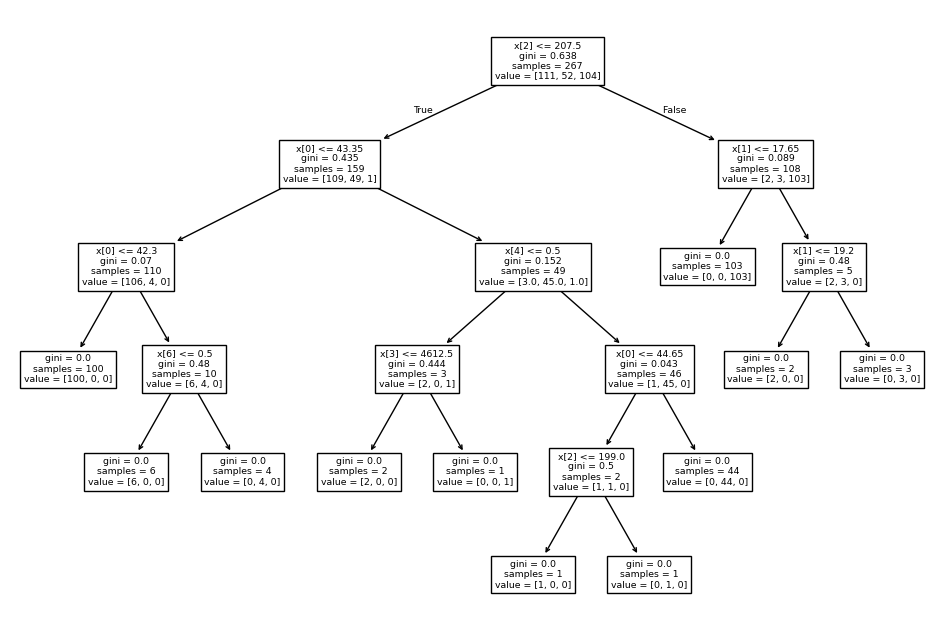

In [ ]:
from sklearn.tree import plot_tree
plt.figure(figsize=(12,8))
plot_tree(model);

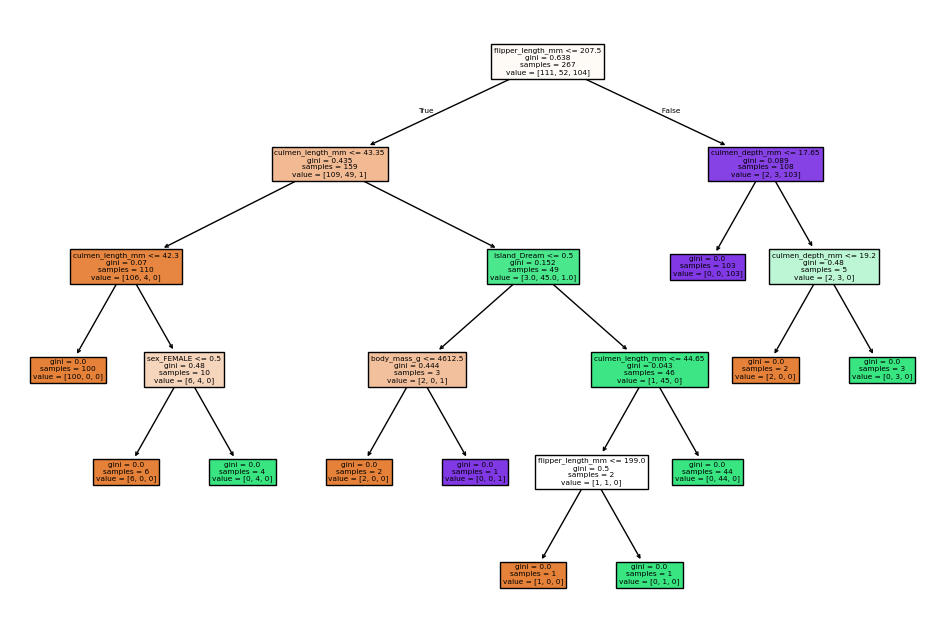

In [ ]:
plt.figure(figsize=(12,8))
plot_tree(model,filled=True,feature_names=x.columns);

In [ ]:
pruned_tree=DecisionTreeClassifier(max_depth=2)
pruned_tree.fit(x_train,y_train)

DecisionTreeClassifier(max_depth=2)

In [ ]:
def report_model(model):
  y_pred=model.predict(x_test)

  print(classification_report(x_test,y_pred))
  plt.figure(figsize=(12,8))
  plot_tree(model,filled=True,feature_names=x.columns)


              precision    recall  f1-score   support

      Adelie       0.95      1.00      0.97        35
   Chinstrap       1.00      0.94      0.97        16
      Gentoo       1.00      0.94      0.97        16

    accuracy                           0.97        67
   macro avg       0.98      0.96      0.97        67
weighted avg       0.97      0.97      0.97        67



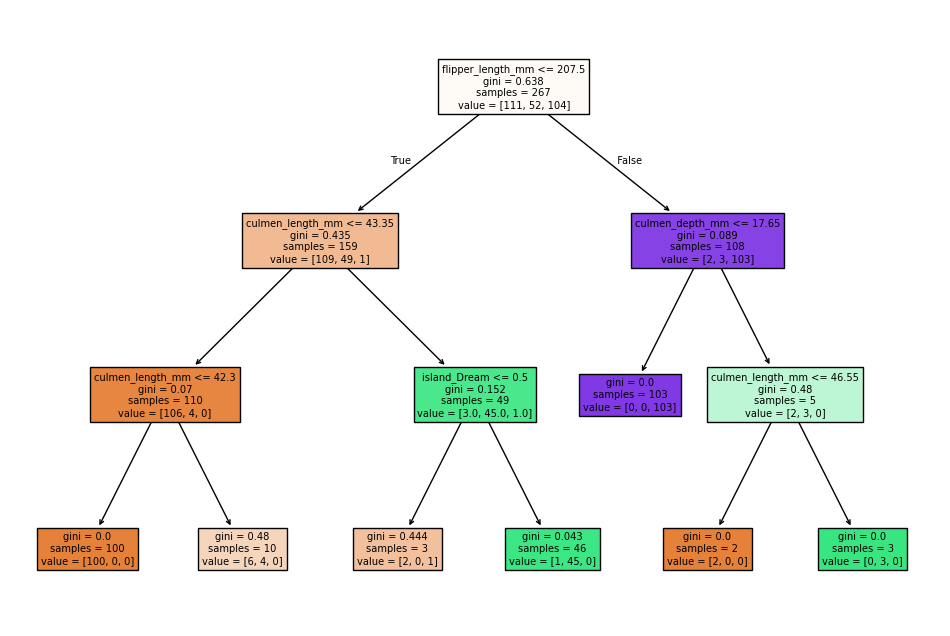

In [ ]:
def report_model(model):
  y_pred=model.predict(x_test)

  print(classification_report(y_test,y_pred)) # Corrected line
  plt.figure(figsize=(12,8))
  plot_tree(model,filled=True,feature_names=x.columns)

report_model(pruned_tree)

              precision    recall  f1-score   support

      Adelie       0.92      1.00      0.96        35
   Chinstrap       1.00      0.88      0.93        16
      Gentoo       1.00      0.94      0.97        16

    accuracy                           0.96        67
   macro avg       0.97      0.94      0.95        67
weighted avg       0.96      0.96      0.95        67



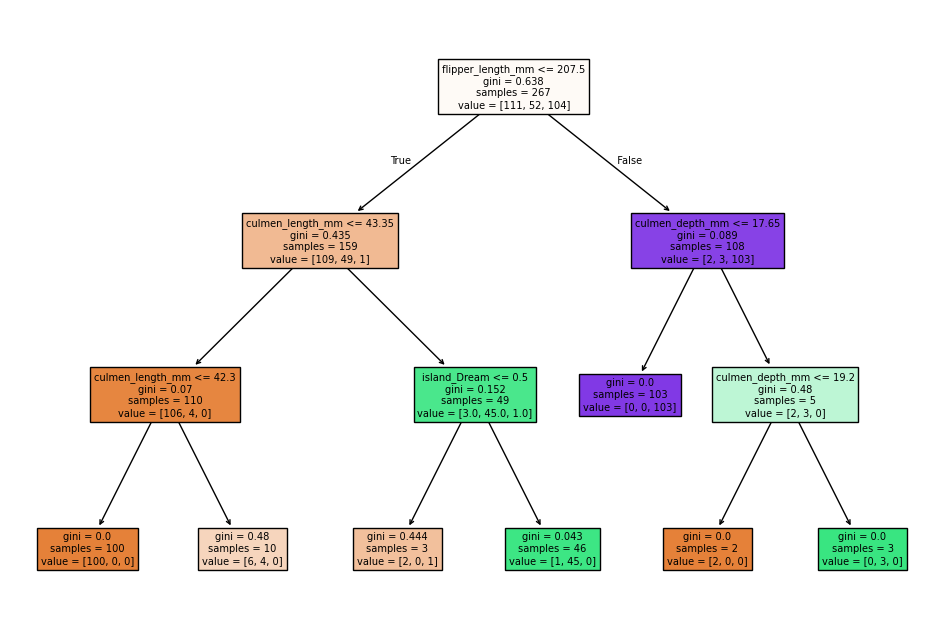

In [ ]:
pruned_tree=DecisionTreeClassifier(max_depth=3)
pruned_tree.fit(x_train,y_train)
report_model(pruned_tree)

              precision    recall  f1-score   support

      Adelie       0.95      1.00      0.97        35
   Chinstrap       1.00      0.88      0.93        16
      Gentoo       1.00      1.00      1.00        16

    accuracy                           0.97        67
   macro avg       0.98      0.96      0.97        67
weighted avg       0.97      0.97      0.97        67



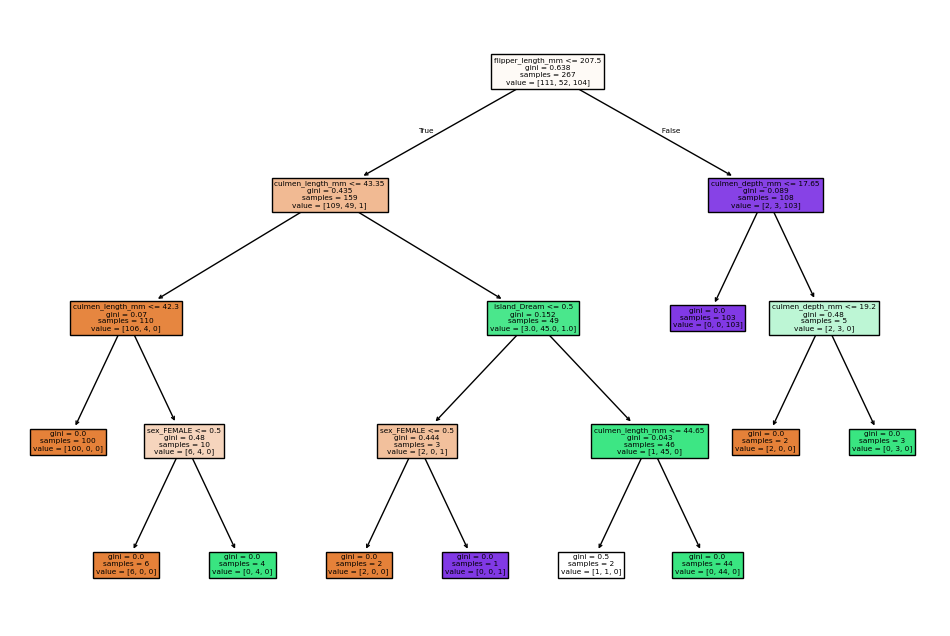

In [ ]:
pruned_tree=DecisionTreeClassifier(max_depth=4)
pruned_tree.fit(x_train,y_train)
report_model(pruned_tree)

In [ ]:
entropy_tree=DecisionTreeClassifier(criterion='entropy')
entropy_tree.fit(x_train,y_train)

DecisionTreeClassifier(criterion='entropy')

              precision    recall  f1-score   support

      Adelie       0.97      1.00      0.99        35
   Chinstrap       1.00      0.94      0.97        16
      Gentoo       1.00      1.00      1.00        16

    accuracy                           0.99        67
   macro avg       0.99      0.98      0.98        67
weighted avg       0.99      0.99      0.98        67



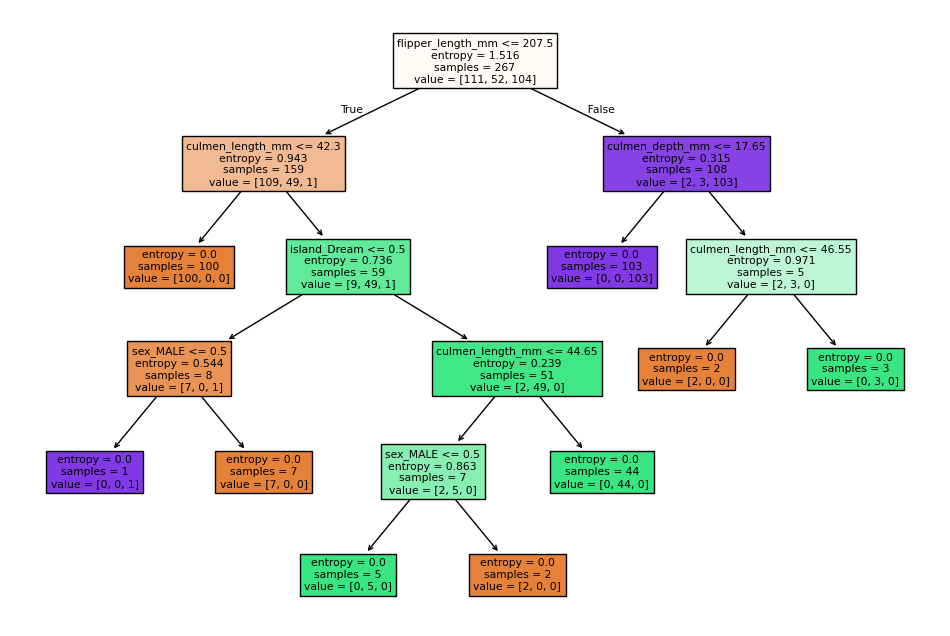

In [ ]:
report_model(entropy_tree)